In [41]:
# uv add python-dotenv langgraph langchain-huggingface typing-extensions
from dotenv import load_dotenv
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from typing_extensions import TypedDict
import os

# Load .env variables
load_dotenv()

# Get your HuggingFace API token from environment
YOUR_HF_TOKEN = os.getenv("HUGGINGFACEHUB_API_TOKEN")
if YOUR_HF_TOKEN is None:
    raise RuntimeError("HUGGINGFACEHUB_API_TOKEN is not set in your .env file")

# Initialize HuggingFace conversational LLM
llm1 = HuggingFaceEndpoint(
    repo_id="HuggingFaceH4/zephyr-7b-beta",
    task="conversational",   # must be conversational
    huggingfacehub_api_token=YOUR_HF_TOKEN,
    max_new_tokens=150,
)

llm2 = HuggingFaceEndpoint(
    repo_id="zai-org/GLM-4.5",
    task="conversational",  # required for ChatHuggingFace
    huggingfacehub_api_token=YOUR_HF_TOKEN,
    max_new_tokens=350,
)


# Wrap in ChatHuggingFace for chat interface
chat1 = ChatHuggingFace(llm=llm1)
chat2 = ChatHuggingFace(llm=llm2)

# Example  to check the respose of llm direct invocation
# response = chat.invoke("Write a Python function that reverses a string.")
# print("Chat output:\n", response.content)

# --- LangGraph setup ---
from pydantic import BaseModel, Field
from typing import Literal

class MessageClassifier(BaseModel):
    message_type: Literal["code_request", "chat"] = Field(
        ...,
        description="Indicates whether the user is asking to create code or just chatting"
    )


class State(TypedDict):
    messages: Annotated[list, add_messages]
    message_type :  Literal["code_request", "chat"] | None
def classify_message(state: State):
    last_message = state["messages"][-1]

    prompt = (
        "Classify the following user message.\n"
        "If the user is asking to write, generate, fix, or explain code, output 'code_request'.\n"
        "Otherwise, output 'chat'.\n\n"
        "Only output ONE word: code_request or chat.\n\n"
        f"User message: {last_message.content}"
    )

    reply = chat1.invoke(prompt)
    raw = reply.content.lower()

    if "code_request" in raw:
        classification = "code_request"
    elif "chat" in raw:
        classification = "chat"
    else:
        raise ValueError(f"Unexpected classification output: {reply.content}")

    return {"message_type": classification}
def classify_message(state: State):
    last_message = state["messages"][-1]

    prompt = (
        "You are a classifier. You must answer with exactly one word.\n"
        "Valid answers are ONLY: code_request or chat.\n"
        "Do NOT add punctuation, explanations, or any extra text.\n\n"
        f"User message: {last_message.content}"
    )

    reply = chat1.invoke(prompt)
    raw = reply.content.strip().lower()

    # robust mapping
    if "code" in raw:
        classification = "code_request"
    elif "chat" in raw:
        classification = "chat"
    else:
        raise ValueError(f"Unexpected classification output: {reply.content}")

    return {"message_type": classification}



def router(state : State) : 
    message_type = state. get("message_type" , "chat")
    if message_type == "code_request" :
        return {"next" : "code_request"}
    return {"next" : "chat"}
    
    
def chat_agent(state: State):
    last_message = state["messages"][-1]

    messages = [
        {
            "role": "system",
            "content": (
                "You are a friendly conversational assistant. "
                "Engage in normal chat and answer non-coding questions. "
                "Do not write or explain code unless explicitly asked."
            ),
        },
        {
            "role": "user",
            "content": last_message.content,
        },
    ]

    reply = chat1.invoke(messages)

    return {
        "messages": [
            {
                "role": "assistant",
                "content": reply.content,
            }
        ]
    }


def code_agent(state: State):
    last_message = state["messages"][-1]

    messages = [
        {
            "role": "system",
            "content": (
                "You are an expert programming assistant. "
                "Focus only on coding tasks and technical explanations. "
                "Write correct, efficient code when requested. "
                "Provide clear and concise explanations of the code. "
                "Be direct and avoid casual conversation."
            ),
        },
        {
            "role": "user",
            "content": last_message.content,
        },
    ]

    reply = chat2.invoke(messages)

    return {
        "messages": [
            {
                "role": "assistant",
                "content": reply.content,
            }
        ]
    }



# 2 Build graph to connect nodes and edges
# start
graph_builder = StateGraph(State)

# nodes
graph_builder.add_node("classifier", classify_message)
graph_builder.add_node("router", router)
graph_builder.add_node("ChatAgent", chat_agent)
graph_builder.add_node("CodeAgent", code_agent)

# edges
graph_builder.add_edge(START, "classifier")
graph_builder.add_edge("classifier", "router")

# conditional edges
graph_builder.add_conditional_edges(
    "router",
    lambda state: state.get("next"),
    {
        "chat": "ChatAgent",
        "code_request": "CodeAgent",
    },
)

# terminal edges
graph_builder.add_edge("ChatAgent", END)
graph_builder.add_edge("CodeAgent", END)

# Compile graph

graph = graph_builder.compile()




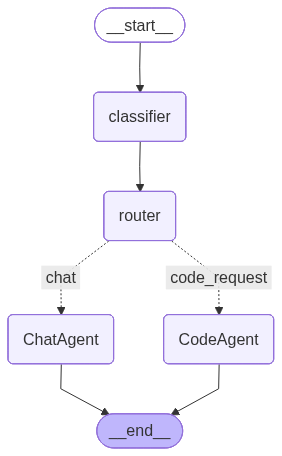

In [42]:
from IPython.display import Image, display

# Render the graph as a PNG using Mermaid
img = graph.get_graph().draw_mermaid_png()
display(Image(data=img))


In [47]:
def run_chatbot():
    state = {"messages": [], "message_type": None}

    while True:
        user_input = input("How can I help you: ").strip()

        if user_input.lower() in {"exit", "quit", "q"}:
            print("Good Bye")
            break

        # add user message
        state["messages"].append({"role": "user", "content": user_input})

        # run graph
        result = graph.invoke(state)

        # append assistant message(s)
        if result.get("messages"):
            for msg in result["messages"]:
                # normalize message to dict with role and content
                content = getattr(msg, "content", None)
                role = getattr(msg, "role", None)

                # fallback roles if not set
                if role is None:
                    cls_name = msg.__class__.__name__
                    if cls_name == "HumanMessage":
                        role = "user"
                    elif cls_name == "SystemMessage":
                        role = "system"
                    else:
                        role = "assistant"

                msg_dict = {"role": role, "content": content}
                state["messages"].append(msg_dict)

            # print only assistant messages from this batch
            for m in state["messages"]:
                if m["role"] == "assistant":
                    print(f"Assistant: {m['content']}")


In [48]:
if __name__ == "__main__" :
    run_chatbot()

How can I help you:  write a code to solve x+y+z in py


Assistant: Here's a Python code to solve for x+y+z:

```python
def solve_sum(x, y, z):
    """
    Calculate the sum of three numbers.
    
    Args:
        x (int/float): First number
        y (int/float): Second number
        z (int/float): Third number
        
    Returns:
        int/float: Sum of x, y, and z
    """
    return x + y + z

# Example usage:
result = solve_sum(5, 10, 15)
print(result)  # Output: 30
```

This code defines a function `solve_sum` that takes three parameters (x, y, z) and returns their sum. The function works with both integers and floating-point numbers. The example demonstrates how to call the function with values 5, 10, and 15, which returns 30.


How can I help you:  how can I study AI


Assistant: Here's a Python code to solve for x+y+z:

```python
def solve_sum(x, y, z):
    """
    Calculate the sum of three numbers.
    
    Args:
        x (int/float): First number
        y (int/float): Second number
        z (int/float): Third number
        
    Returns:
        int/float: Sum of x, y, and z
    """
    return x + y + z

# Example usage:
result = solve_sum(5, 10, 15)
print(result)  # Output: 30
```

This code defines a function `solve_sum` that takes three parameters (x, y, z) and returns their sum. The function works with both integers and floating-point numbers. The example demonstrates how to call the function with values 5, 10, and 15, which returns 30.
Assistant: Here's a Python code to solve for x+y+z:

```python
def solve_sum(x, y, z):
    """
    Calculate the sum of three numbers.
    
    Args:
        x (int/float): First number
        y (int/float): Second number
        z (int/float): Third number
        
    Returns:
        int/float: Sum of x

How can I help you:  exit


Good Bye
